# DEEP IRT–VAE Scoring

This notebook converts raw **DEEP (Developmental Assessment on an E-Platform)** game responses into latent ability scores using an IRT-constrained Variational Autoencoder with a **Graded Response Model (GRM)** decoder for ordinal items.

## What this notebook does

1. Loads the preprocessed DEEP CSV and filters to children aged ≥ `AGE_MIN_YEARS` (default: 3 years).
2. For each response type (`highest_level`, `accuracy`, `end_prop`, and all combined), selects the matching columns.
3. Trains an **Encoder–Decoder VAE** where the decoder follows the **Graded Response Model (GRM)**:  
   `P(Y ≥ k | θ) = σ(a · (θ − b_k))` with cumulative category probabilities derived by differencing.
4. Scores all children using the encoder posterior mean `μ` as the latent ability `θ`.
5. Combines subscale scores into a single output CSV.

## Inputs required

| File | Description |
|---|---|
| `DEEP_processed_data.csv` | Preprocessed DEEP responses. Columns: `child_ids`, `Age`, and game-item columns named `{GAME}_{TYPE}_{item}` (e.g. `ST_HIGHESTLEVEL_1`). Ordinal integers; NaN = not played. |

## Outputs produced

| File | Description |
|---|---|
| `DEEP_Deep_abilities_3.csv` | Combined scores: `child_ids`, `Age`, `highest_level`, `accuracy`, `end_prop`, `total_DEEP` |
| Individual CSVs | One per `SCORING_RUNS` entry, e.g. `highest_level_deep_irt_score_GRM_3.csv` |

## Key difference from MDAT
MDAT uses a **binary (2PL)** decoder; DEEP uses an **ordinal (GRM)** decoder because game responses have multiple ordered categories (levels 0–4). The GRM assigns category probabilities by taking differences of cumulative logistic functions.

In [1]:
import pandas as pd
import numpy as np
import torch
from torch.utils.data import Dataset

DATA_PATH = "DEEP_processed_data.csv"
AGE_MIN_YEARS = 3

SCORING_RUNS = {
    "highest_level": {
        "patterns": ("HIGHESTLEVEL",),
        "output_prefix": "highest_level_deep_irt_score_GRM",
    },
    "accuracy": {
        "patterns": ("ACCURACY",),
        "output_prefix": "ACCURACY_deep_irt_score_GRM",
    },
    "end_prop": {
        "patterns": ("EndTime_proptimer",),
        "output_prefix": "End_propTimer_deep_irt_score_GRM",
    },
    "total_DEEP": {
        "patterns": ("HIGHESTLEVEL", "ACCURACY", "EndTime_proptimer"),
        "output_prefix": "ALL_deep_irt_score_GRM",
    },
}

COMBINED_OUTPUT_PREFIX = "DEEP_Deep_abilities"
EXCLUDED_COLUMNS = {"dat$Sample.Group"}

LATENT_DIM = 1
EPOCHS = 200
BATCH_SIZE = 32
LEARNING_RATE = 1e-3
TEST_SIZE = 0.01
RANDOM_STATE = 42
SHOW_PLOTS = True


## Data Preparation

`prepare_deep_inputs` loads and pre-processes the DEEP data:
- Filters to children with `Age > AGE_MIN_YEARS`.
- Selects columns whose names contain any of the `patterns` for the current run (e.g. `"HIGHESTLEVEL"`, `"ACCURACY"`, `"EndTime_proptimer"`).
- Builds a long-integer response tensor `Y` (0-indexed category labels) and a float mask `M` (1 = observed, 0 = NaN).
- Normalises ages to zero mean and unit variance for use as encoder input.

In [2]:
# Optional helper to create an exclusive 20% DEEP child_id split.

# import pandas as pd
# from sklearn.model_selection import train_test_split

# data = pd.read_csv(DATA_PATH)

# child_ids = data["child_ids"]

# train_ids, test_ids = train_test_split(
#     child_ids,
#     test_size=0.2,
#     shuffle=True,
#     random_state=42
# )

# pd.DataFrame({"child_ids": train_ids}).to_csv(
#     "splits/train_child_ids.csv", index=False
# )
# pd.DataFrame({"child_ids": test_ids}).to_csv(
#     "splits/test_child_ids.csv", index=False
# )


In [3]:
def format_age_tag(age_min_years):
    return f"{age_min_years:g}"


def build_output_filename(prefix, age_min_years=AGE_MIN_YEARS):
    return f"{prefix}_{format_age_tag(age_min_years)}.csv"


def prepare_deep_inputs(dataframe, patterns, age_min_years=AGE_MIN_YEARS, verbose=True):
    filtered_data = dataframe.loc[dataframe["Age"] > age_min_years].copy()

    ids = filtered_data["child_ids"].copy()
    ages = filtered_data["Age"].to_numpy()
    ages_norm = (ages - ages.mean()) / ages.std()
    ages_tensor = torch.tensor(ages_norm, dtype=torch.float32).unsqueeze(1)

    feature_data = filtered_data.drop(columns=["child_ids", "Age"])
    pattern_list = patterns if isinstance(patterns, (list, tuple)) else (patterns,)

    selected_cols = [
        col
        for col in feature_data.columns
        if any(pattern in col for pattern in pattern_list) and col not in EXCLUDED_COLUMNS
    ]

    if not selected_cols:
        raise ValueError(f"No columns matched patterns {pattern_list} for age > {age_min_years}.")

    if verbose:
        print(f"Selected columns for {pattern_list}: {selected_cols}")

    feature_data = feature_data[selected_cols]

    raw = feature_data.to_numpy(dtype=np.float32)
    M = torch.tensor((~np.isnan(raw)).astype(np.float32))
    Y = torch.tensor(np.nan_to_num(raw, nan=0.0).astype(np.int64))

    return {
        "filtered_data": filtered_data,
        "ids": ids,
        "ages": ages,
        "ages_norm": ages_norm,
        "ages_tensor": ages_tensor,
        "feature_data": feature_data,
        "selected_cols": selected_cols,
        "Y": Y,
        "M": M,
    }


In [4]:
class StudentDataset(Dataset):
    """Dataset wrapper for responses, observation masks, and normalized age."""
    def __init__(self, Y, M, ages):
        self.Y = torch.as_tensor(Y, dtype=torch.long)        # categorical labels
        self.M = torch.as_tensor(M, dtype=torch.float32)     # mask
        self.ages = torch.as_tensor(ages, dtype=torch.float32).unsqueeze(1) 

    def __len__(self):
        return len(self.Y)

    def __getitem__(self, idx):
        return self.Y[idx], self.M[idx], self.ages[idx]



## Model Architecture

### Encoder
An MLP that maps the concatenated `[Y.float(), M, age_normalised]` to `(μ, logvar)`. The encoder sees both the responses and the mask so it can distinguish "answered 0" from "not answered". An auxiliary `age_predictor` head maps `μ` to a predicted age (used for monitoring, not optimised in the default configuration).

### Decoder — Graded Response Model (GRM)
The GRM decoder computes ordered-category probabilities for each item:

```
P(Y_ij = k | θ_i) = P(Y ≥ k | θ_i) − P(Y ≥ k+1 | θ_i)
P(Y ≥ k | θ_i)    = σ(a_j · (θ_i − b_jk))
```

Parameters:
- `a_j` — item discrimination (one per item), initialised to 1.
- `b_jk` — ordered thresholds (one per category boundary per item), initialised to a linear grid from −1 to +1.
- `theta_proj` — a linear layer mapping the latent vector to a scalar `θ` (needed when `LATENT_DIM > 1`).

The final output is a `[B, n_items, max_categories]` probability tensor.

In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class Encoder(nn.Module):
    def __init__(self, input_dim=315, hidden_dims=[128, 64, 32, 8, 4], latent_dim=4, dropout=0.2):
        super().__init__()
        
        # Build MLP layers from input_dim through hidden_dims
        dims = [input_dim] + hidden_dims 
        self.mlp = nn.ModuleList([
            nn.Linear(dims[i], dims[i+1]) for i in range(len(dims)-1)
        ])
        
        self.fc_mu = nn.Linear(hidden_dims[-1], latent_dim)
        self.age_predictor = nn.Linear(latent_dim, 1) 

        self.fc_logvar = nn.Linear(hidden_dims[-1], latent_dim)
        # self.dropout = nn.Dropout(dropout)

    def forward(self, y, m, age):
        x = torch.cat([y, m, age], dim=-1)  # [B, input_dim]
        for layer in self.mlp:
            x = torch.tanh(layer(x))
            # Uncomment below if you want to apply dropout at each layer
            # x = self.dropout(x)
        mu = self.fc_mu(x)
        age_hat = self.age_predictor(mu)  # shape [B, 1]
        # age_hat = self.age_predictor(mu.detach())

        logvar = self.fc_logvar(x)
        return mu, logvar, age_hat


In [6]:
import torch
import torch.nn as nn

class Decoder(nn.Module):
    def __init__(self, latent_dim=1, n_items=84, max_categories=5):
        """
        GRM-style decoder for ordinal responses.
        
        latent_dim: dimension of latent ability vector
        n_items: number of items
        max_categories: maximum number of categories across all items
        """
        super().__init__()
        
        # Discrimination parameters per item (a_j)
        self.a = nn.Parameter(torch.ones(n_items))  # shape [n_items]
        
        # Thresholds per item (b_jk), shape [n_items, max_categories-1]
        self.b = nn.Parameter(torch.linspace(-1.0, 1.0, max_categories-1).repeat(n_items, 1))
        
        # Project latent_dim -> single theta per person
        self.theta_proj = nn.Linear(latent_dim, 1)
    
    def forward(self, z):
        """
        z: latent ability vector from encoder, shape [B, latent_dim]
        returns: probs [B, n_items, max_categories]
        """
        B = z.size(0)
        n_items = self.a.size(0)
        T = self.b.size(1)  # number of thresholds = max_categories-1
        
        # Project latent_dim -> single theta
        theta = self.theta_proj(z).squeeze(-1)    # [B]
        theta = theta.unsqueeze(1)                # [B, 1] for broadcasting
        
        # Expand to items and thresholds
        theta_exp = theta.expand(B, n_items).unsqueeze(-1)   # [B, n_items, 1]
        b = self.b.unsqueeze(0)                               # [1, n_items, T]
        a = self.a.unsqueeze(0).unsqueeze(-1)               # [1, n_items, 1]
        
        # Cumulative probabilities P(Y >= k)
        P_ge = torch.sigmoid(a * (theta_exp - b))           # [B, n_items, T]
        
        probs = torch.zeros(B, n_items, T+1, device=z.device)

        # k=0
        probs[:, :, 0] = 1 - P_ge[:, :, 0]  

        # k=1..T-1
        probs[:, :, 1:T] = P_ge[:, :, :-1] - P_ge[:, :, 1:]

        # k=T (last category)
        probs[:, :, T] = P_ge[:, :, -1]

                
        return probs


In [7]:
def deterministic_latent(mu, logvar=None):
    """Keep the latent representation deterministic by using the encoder mean."""
    return mu

sample_latent = deterministic_latent


## Loss Function (ELBO for Ordinal Responses)

The ELBO for ordinal responses uses categorical log-likelihood in place of BCE:

```
Reconstruction = Σ_{i,j} M_ij · log P(Y_ij = y_ij | θ_i)   /  Σ M_ij
KL             = −0.5 · Σ (1 + logvar − μ² − exp(logvar))
Total loss     = −(Reconstruction − β · KL) + γ · MSE(age_hat, age)
```

`torch.gather` is used to efficiently extract `P(Y=y_ij)` from the `[B, n_items, max_categories]` probability tensor. A small floor of `1e-8` prevents `log(0)`. By default `γ=0` (age supervision disabled).

In [8]:
def elbo_loss(mu, logvar, probs, y, m, age_hat=None, age_tensor=None,
              beta=1.0, gamma=0.0, delta=0.0):
    """
    probs: [B, n_items, max_categories]
    y: [B, n_items] (long tensor with category indices)
    m: [B, n_items] (float mask: 1 if observed, 0 if missing)
    """
    B, n_items, max_c = probs.size()

    # Gather probabilities of observed responses
    y_unsq = y.unsqueeze(-1)  # [B, n_items, 1]
    gathered = torch.gather(probs, 2, y_unsq).squeeze(-1)  # [B, n_items]
    
    # Avoid log(0)
    gathered = torch.clamp(gathered, min=1e-8)

    # Reconstruction log-likelihood (masked)
    recon = (torch.log(gathered) * m).sum() / m.sum()

    # KL divergence (per sample, then average)
    kl = -0.5 * torch.mean(torch.sum(1 + logvar - mu.pow(2) - logvar.exp(), dim=1))

    # Age regression loss (optional)
    if age_hat is not None and age_tensor is not None:
        age_loss = torch.nn.functional.mse_loss(age_hat, age_tensor, reduction="mean")
    else:
        age_loss = torch.tensor(0.0, device=mu.device)

    # Total ELBO-style loss
    loss = -(recon - beta * kl) + gamma * age_loss

    return loss, -recon, kl, age_loss


## Training and Scoring

`train_and_score_configuration` runs the full pipeline for one response-type run:

1. **Split**: Random 99/1 train/test split (small test set used only for held-out NLL and accuracy).
2. **Training**: 200 epochs, Adam optimiser. Per-epoch: forward pass → GRM probabilities → ELBO loss → backward.
3. **Test evaluation**: Masked NLL per observed response, and argmax accuracy (most probable category vs. true category).
4. **Scoring**: All children are passed through the trained encoder; `μ[:,0]` is used as `θ`. Sign is flipped if the raw correlation with age is negative.
5. **Plots**: Item-wise accuracy histogram and ability-vs-age scatter (set `SHOW_PLOTS = False` to skip).

In [9]:
from torch.optim import Adam
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt


def train_and_score_configuration(raw_data, run_key, config, age_min_years=AGE_MIN_YEARS, show_plots=SHOW_PLOTS):
    run_inputs = prepare_deep_inputs(
        raw_data,
        patterns=config["patterns"],
        age_min_years=age_min_years,
        verbose=False,
    )

    Y = run_inputs["Y"]
    M = run_inputs["M"]
    ages_norm = run_inputs["ages_norm"]

    print(f"\n=== Running {run_key} | age > {age_min_years:g} ===")
    print(f"Selected {len(run_inputs['selected_cols'])} columns")

    Y_train, Y_test, M_train, M_test, ages_train, ages_test = train_test_split(
        Y,
        M,
        ages_norm,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
    )
    print(f"Train size: {Y_train.shape[0]}, Test size: {Y_test.shape[0]}")

    num_items = Y.shape[1]
    max_categories = int(Y.max().item() + 1)
    print(f"Items: {num_items}, Max categories: {max_categories}")

    encoder = Encoder(input_dim=2 * num_items + 1, latent_dim=LATENT_DIM)
    decoder = Decoder(latent_dim=LATENT_DIM, n_items=num_items, max_categories=max_categories)

    params = list(encoder.parameters()) + list(decoder.parameters())
    optimizer = Adam(params, lr=LEARNING_RATE)

    dataset = StudentDataset(Y_train, M_train, ages_train)
    loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

    for epoch in range(EPOCHS):
        encoder.train()
        decoder.train()
        total_loss, total_recon, total_kl, total_age_loss = 0, 0, 0, 0

        for y_batch, m_batch, age_batch in loader:
            optimizer.zero_grad()

            mu, logvar, age_hat = encoder(y_batch.float(), m_batch, age_batch)
            z = sample_latent(mu, logvar)
            pred_probs = decoder(z)

            loss, recon, kl, age_loss = elbo_loss(
                mu,
                logvar,
                pred_probs,
                y_batch,
                m_batch,
                age_hat=age_hat,
                age_tensor=age_batch,
                beta=1.0,
                gamma=0.0,
            )

            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            total_recon += recon.item()
            total_kl += kl.item()
            total_age_loss += age_loss.item()

        print(
            f"Epoch {epoch + 1:03d} | Total Loss: {total_loss:.2f} | "
            f"Recon: {total_recon:.2f} | KL: {total_kl:.2f} | Age: {total_age_loss:.2f}"
        )

    Y_test_tensor = torch.as_tensor(Y_test, dtype=torch.long)
    M_test_tensor = torch.as_tensor(M_test, dtype=torch.float32)
    ages_test_tensor = torch.as_tensor(ages_test, dtype=torch.float32).unsqueeze(1)

    encoder.eval()
    decoder.eval()

    with torch.no_grad():
        mu_test, _, _ = encoder(Y_test_tensor.float(), M_test_tensor, ages_test_tensor)
        pred_probs = decoder(mu_test)

        y_unsq = Y_test_tensor.unsqueeze(-1)
        gathered = torch.gather(pred_probs, 2, y_unsq).squeeze(-1)
        gathered = torch.clamp(gathered, min=1e-8)

        recon_loss_matrix = -torch.log(gathered) * M_test_tensor
        total_loss = recon_loss_matrix.sum().item()
        total_known = M_test_tensor.sum().item()
        avg_loss = total_loss / total_known

        pred_labels = torch.argmax(pred_probs, dim=-1)
        accuracy = ((pred_labels == Y_test_tensor) * M_test_tensor).sum().item() / total_known

        accs = []
        for j in range(Y_test_tensor.shape[1]):
            m_j = M_test_tensor[:, j]
            if m_j.sum() == 0:
                continue
            y_j = Y_test_tensor[:, j]
            p_j = pred_labels[:, j]
            acc = ((p_j == y_j) * m_j).sum() / m_j.sum()
            accs.append(acc.item())

    print(f"Total recon loss (NLL): {total_loss:.2f}")
    print(f"Avg recon loss per observed response: {avg_loss:.6f}")
    print(f"Observed-response reconstruction accuracy: {accuracy * 100:.2f}%")

    score_ids = run_inputs["ids"]
    score_ages = run_inputs["ages"]
    score_ages_tensor = run_inputs["ages_tensor"]
    score_Y = run_inputs["Y"]
    score_M = run_inputs["M"]

    with torch.no_grad():
        mu_all, _, _ = encoder(score_Y.float(), score_M, score_ages_tensor)
        theta_all = mu_all[:, 0].cpu().numpy()

    if np.corrcoef(score_ages, theta_all)[0, 1] < 0:
        theta_all = -theta_all

    score_df = pd.DataFrame({
        "child_ids": score_ids,
        "Age": score_ages,
        "Ability": theta_all.squeeze(),
    })
    output_path = build_output_filename(config["output_prefix"], age_min_years)
    # score_df.to_csv(output_path, index=False)
    print(f"Saved {output_path}")

    if show_plots:
        plt.figure(figsize=(8, 4))
        plt.hist(accs, bins=30)
        plt.xlabel("Item-wise Accuracy")
        plt.ylabel("Number of Items")
        plt.title(f"Observed-response Reconstruction Accuracy per Item: {run_key}")
        plt.grid(True)
        plt.show()

        plt.figure(figsize=(10, 6))
        plt.scatter(score_ages, theta_all, alpha=0.6, s=15)
        plt.xlabel("Age")
        plt.ylabel("Latent Ability (theta)")
        plt.title(f"Estimated Ability vs Age: {run_key}")
        plt.grid(True)
        plt.show()

    return {
        "run_key": run_key,
        "output_path": output_path,
        "score_df": score_df,
        "selected_cols": run_inputs["selected_cols"],
        "train_size": int(Y_train.shape[0]),
        "test_size": int(Y_test.shape[0]),
        "num_items": int(num_items),
        "max_categories": int(max_categories),
        "avg_loss": float(avg_loss),
        "accuracy": float(accuracy),
    }


## Combining Subscale Scores

`combine_scoring_outputs` merges the four response-type score DataFrames on `child_ids` (inner join) and saves the combined CSV. The four subscales are: `highest_level`, `accuracy`, `end_prop`, `total_DEEP`.

In [10]:
def combine_scoring_outputs(run_outputs, age_min_years=AGE_MIN_YEARS):
    highest_level_df = run_outputs["highest_level"]["score_df"].rename(columns={"Ability": "highest_level"})
    accuracy_df = run_outputs["accuracy"]["score_df"].rename(columns={"Ability": "accuracy"})
    end_prop_df = run_outputs["end_prop"]["score_df"].rename(columns={"Ability": "end_prop"})
    total_deep_df = run_outputs["total_DEEP"]["score_df"].rename(columns={"Ability": "total_DEEP"})

    combined_scores = (
        highest_level_df
        .merge(accuracy_df[["child_ids", "accuracy"]], on="child_ids", how="inner")
        .merge(end_prop_df[["child_ids", "end_prop"]], on="child_ids", how="inner")
        .merge(total_deep_df[["child_ids", "total_DEEP"]], on="child_ids", how="inner")
    )

    combined_scores = combined_scores[[
        "child_ids",
        "Age",
        "highest_level",
        "accuracy",
        "end_prop",
        "total_DEEP",
    ]]

    combined_output_path = build_output_filename(COMBINED_OUTPUT_PREFIX, age_min_years)
    combined_scores.to_csv(combined_output_path, index=False)
    print(f"Saved {combined_output_path}")

    return combined_scores, combined_output_path


## Run All Response-Type Configurations

Iterates over the four entries in `SCORING_RUNS` and trains one GRM–VAE per response type. Training 4 models × 200 epochs takes approximately 5–15 minutes depending on dataset size and hardware. Set `SHOW_PLOTS = False` to suppress figures.


=== Running highest_level | age > 3 ===
Selected 10 columns
Train size: 1959, Test size: 20
Items: 10, Max categories: 16
Epoch 001 | Total Loss: 186.40 | Recon: 185.88 | KL: 0.52 | Age: 66.92
Epoch 002 | Total Loss: 168.77 | Recon: 168.69 | KL: 0.08 | Age: 65.39
Epoch 003 | Total Loss: 157.61 | Recon: 157.52 | KL: 0.09 | Age: 64.81
Epoch 004 | Total Loss: 149.27 | Recon: 149.15 | KL: 0.11 | Age: 63.62
Epoch 005 | Total Loss: 142.16 | Recon: 141.99 | KL: 0.17 | Age: 63.28
Epoch 006 | Total Loss: 136.29 | Recon: 136.04 | KL: 0.24 | Age: 62.62
Epoch 007 | Total Loss: 131.03 | Recon: 130.69 | KL: 0.33 | Age: 62.41
Epoch 008 | Total Loss: 126.53 | Recon: 126.09 | KL: 0.44 | Age: 62.18
Epoch 009 | Total Loss: 122.17 | Recon: 121.61 | KL: 0.55 | Age: 61.08
Epoch 010 | Total Loss: 118.52 | Recon: 117.86 | KL: 0.66 | Age: 60.69
Epoch 011 | Total Loss: 115.02 | Recon: 114.27 | KL: 0.75 | Age: 60.49
Epoch 012 | Total Loss: 112.10 | Recon: 111.27 | KL: 0.83 | Age: 59.82
Epoch 013 | Total Loss: 1

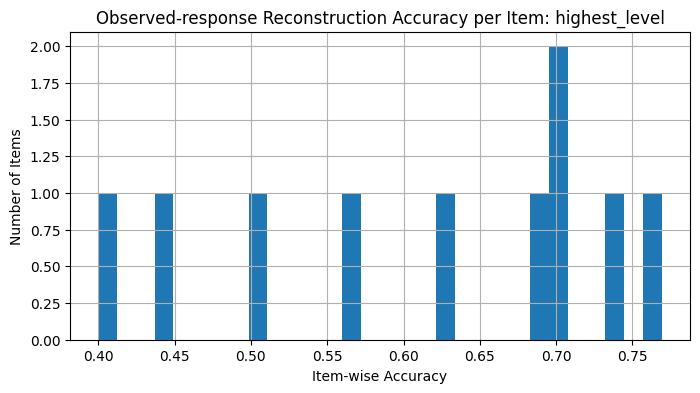

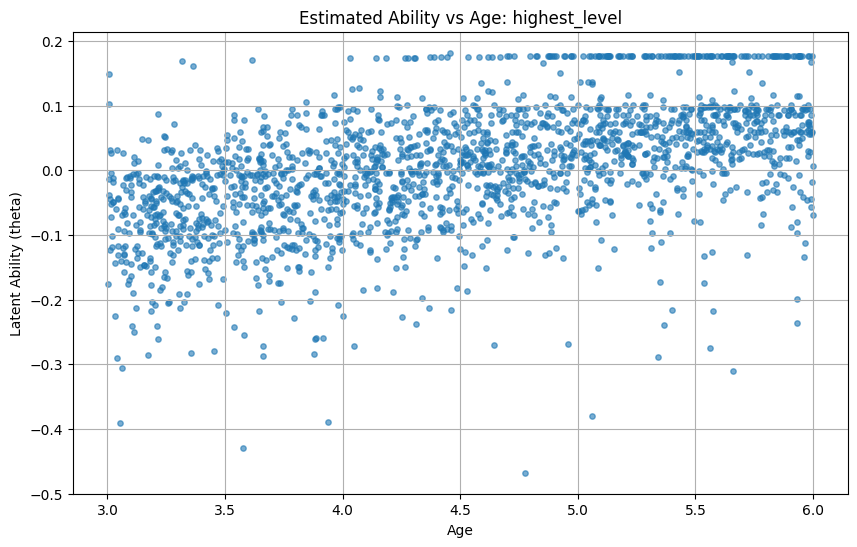


=== Running accuracy | age > 3 ===
Selected 89 columns
Train size: 1959, Test size: 20
Items: 89, Max categories: 4
Epoch 001 | Total Loss: 77.82 | Recon: 75.80 | KL: 2.02 | Age: 74.98
Epoch 002 | Total Loss: 74.13 | Recon: 72.24 | KL: 1.89 | Age: 77.10
Epoch 003 | Total Loss: 71.17 | Recon: 69.35 | KL: 1.82 | Age: 76.62
Epoch 004 | Total Loss: 68.62 | Recon: 66.89 | KL: 1.73 | Age: 76.41
Epoch 005 | Total Loss: 66.34 | Recon: 64.68 | KL: 1.66 | Age: 76.01
Epoch 006 | Total Loss: 64.26 | Recon: 62.68 | KL: 1.59 | Age: 77.16
Epoch 007 | Total Loss: 62.52 | Recon: 61.04 | KL: 1.48 | Age: 76.75
Epoch 008 | Total Loss: 60.88 | Recon: 59.46 | KL: 1.42 | Age: 76.47
Epoch 009 | Total Loss: 59.51 | Recon: 58.17 | KL: 1.34 | Age: 77.14
Epoch 010 | Total Loss: 58.37 | Recon: 57.10 | KL: 1.27 | Age: 75.73
Epoch 011 | Total Loss: 57.32 | Recon: 56.10 | KL: 1.22 | Age: 76.06
Epoch 012 | Total Loss: 56.39 | Recon: 55.20 | KL: 1.19 | Age: 75.44
Epoch 013 | Total Loss: 55.57 | Recon: 54.41 | KL: 1.16

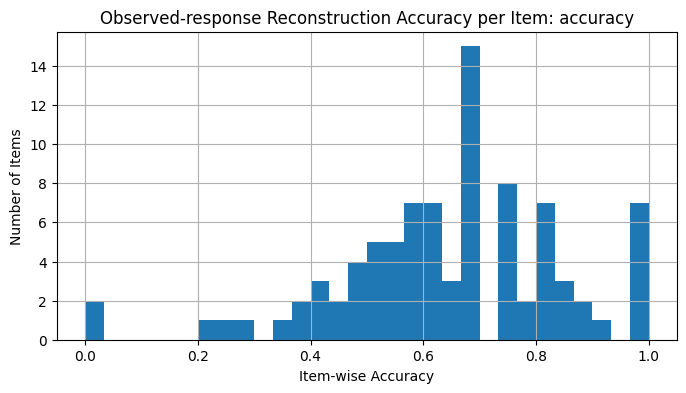

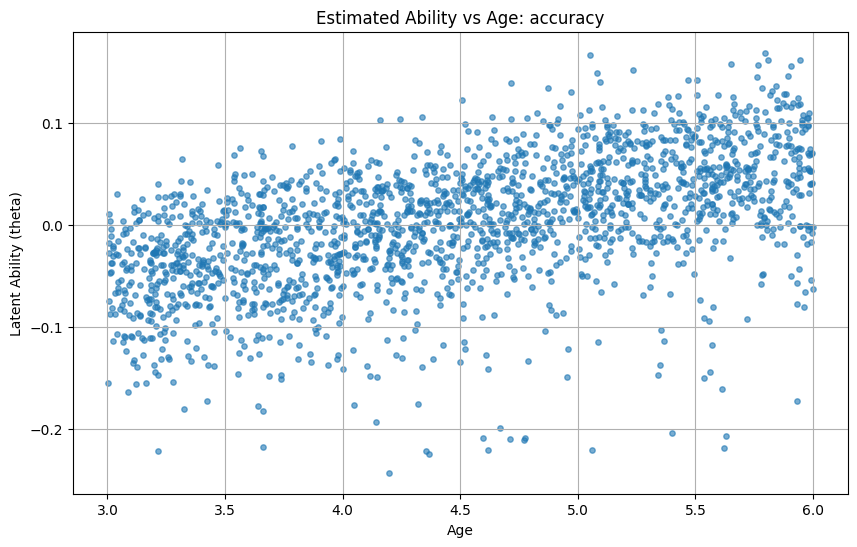


=== Running end_prop | age > 3 ===
Selected 80 columns
Train size: 1959, Test size: 20
Items: 80, Max categories: 4
Epoch 001 | Total Loss: 60.57 | Recon: 59.29 | KL: 1.28 | Age: 65.90
Epoch 002 | Total Loss: 57.14 | Recon: 55.94 | KL: 1.20 | Age: 65.35
Epoch 003 | Total Loss: 54.00 | Recon: 52.72 | KL: 1.29 | Age: 66.15
Epoch 004 | Total Loss: 51.12 | Recon: 49.72 | KL: 1.41 | Age: 66.01
Epoch 005 | Total Loss: 48.29 | Recon: 46.85 | KL: 1.44 | Age: 65.68
Epoch 006 | Total Loss: 45.66 | Recon: 44.27 | KL: 1.39 | Age: 65.66
Epoch 007 | Total Loss: 43.38 | Recon: 42.07 | KL: 1.31 | Age: 65.74
Epoch 008 | Total Loss: 41.36 | Recon: 40.15 | KL: 1.21 | Age: 66.03
Epoch 009 | Total Loss: 39.83 | Recon: 38.77 | KL: 1.07 | Age: 66.18
Epoch 010 | Total Loss: 38.50 | Recon: 37.53 | KL: 0.96 | Age: 65.64
Epoch 011 | Total Loss: 37.45 | Recon: 36.56 | KL: 0.89 | Age: 66.03
Epoch 012 | Total Loss: 36.61 | Recon: 35.78 | KL: 0.82 | Age: 66.12
Epoch 013 | Total Loss: 35.80 | Recon: 35.01 | KL: 0.79

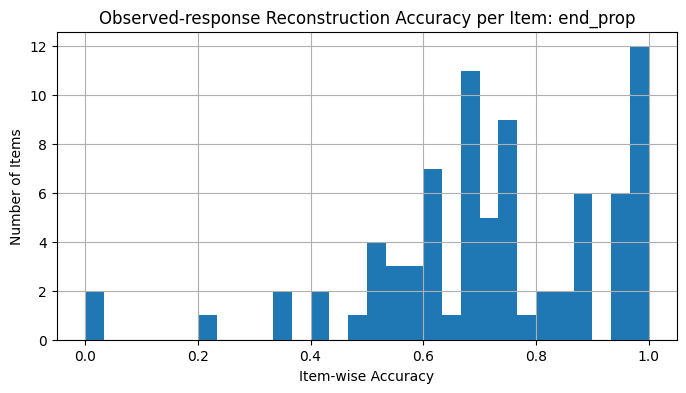

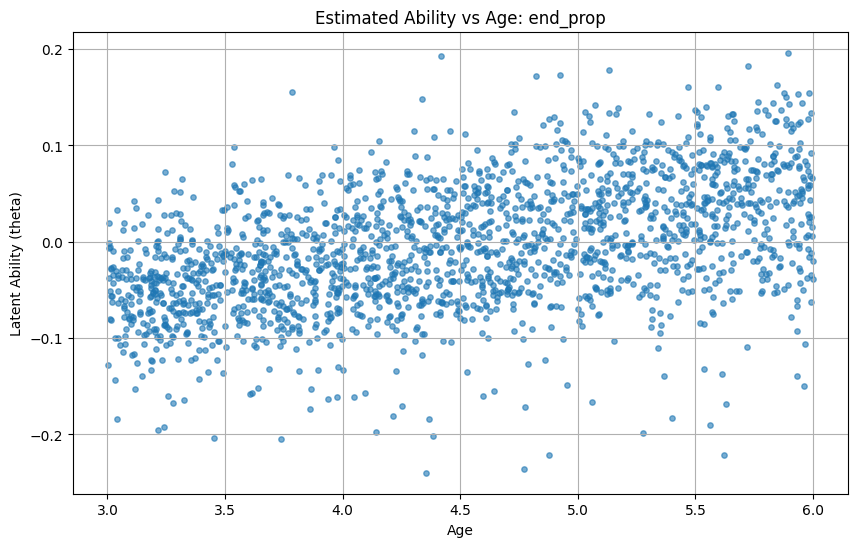


=== Running total_DEEP | age > 3 ===
Selected 179 columns
Train size: 1959, Test size: 20
Items: 179, Max categories: 16
Epoch 001 | Total Loss: 191.72 | Recon: 191.68 | KL: 0.04 | Age: 65.00
Epoch 002 | Total Loss: 170.49 | Recon: 170.47 | KL: 0.02 | Age: 64.69
Epoch 003 | Total Loss: 155.90 | Recon: 155.89 | KL: 0.01 | Age: 64.97
Epoch 004 | Total Loss: 144.41 | Recon: 144.40 | KL: 0.01 | Age: 64.84
Epoch 005 | Total Loss: 134.83 | Recon: 134.81 | KL: 0.01 | Age: 65.14
Epoch 006 | Total Loss: 126.69 | Recon: 126.67 | KL: 0.02 | Age: 65.44
Epoch 007 | Total Loss: 119.46 | Recon: 119.43 | KL: 0.03 | Age: 65.11
Epoch 008 | Total Loss: 113.05 | Recon: 113.00 | KL: 0.05 | Age: 64.88
Epoch 009 | Total Loss: 107.24 | Recon: 107.18 | KL: 0.06 | Age: 65.47
Epoch 010 | Total Loss: 102.08 | Recon: 102.00 | KL: 0.08 | Age: 66.04
Epoch 011 | Total Loss: 97.30 | Recon: 97.20 | KL: 0.10 | Age: 65.67
Epoch 012 | Total Loss: 93.04 | Recon: 92.93 | KL: 0.11 | Age: 65.41
Epoch 013 | Total Loss: 89.20 

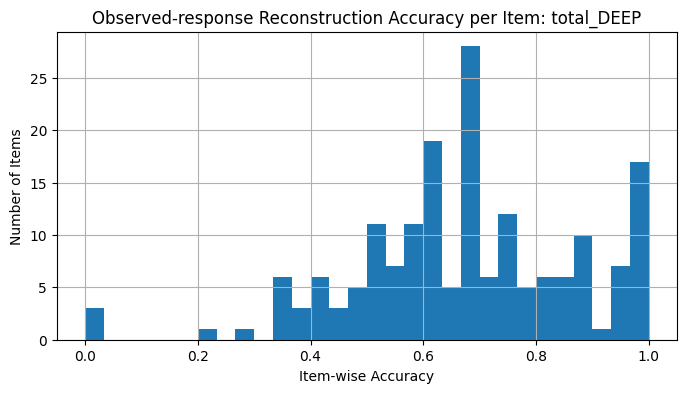

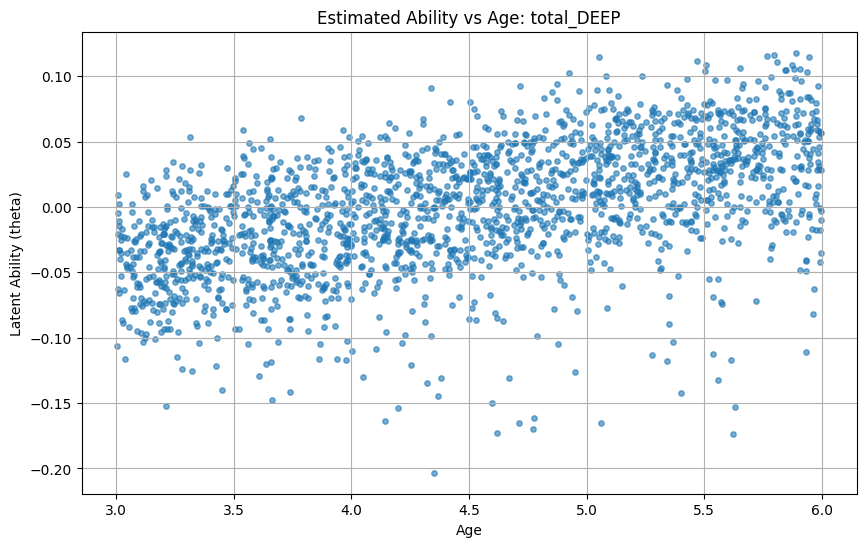

,run_key,output_path,num_items,train_size,test_size,avg_loss,accuracy
0,highest_level,highest_level_deep_irt_score_GRM_3.csv,10,1959,20,1.162614,0.616279
1,accuracy,ACCURACY_deep_irt_score_GRM_3.csv,89,1959,20,0.803849,0.634845
2,end_prop,End_propTimer_deep_irt_score_GRM_3.csv,80,1959,20,0.550327,0.766417
3,total_DEEP,ALL_deep_irt_score_GRM_3.csv,179,1959,20,0.742127,0.684569


In [11]:
raw_deep_data = pd.read_csv(DATA_PATH)

run_outputs = {}
run_summaries = []

for run_key, config in SCORING_RUNS.items():
    run_result = train_and_score_configuration(
        raw_deep_data,
        run_key,
        config,
        age_min_years=AGE_MIN_YEARS,
        show_plots=SHOW_PLOTS,
    )
    run_outputs[run_key] = run_result
    run_summaries.append({
        "run_key": run_result["run_key"],
        "output_path": run_result["output_path"],
        "num_items": run_result["num_items"],
        "train_size": run_result["train_size"],
        "test_size": run_result["test_size"],
        "avg_loss": run_result["avg_loss"],
        "accuracy": run_result["accuracy"],
    })

run_summary_df = pd.DataFrame(run_summaries)
run_summary_df


In [12]:
combined_scores, combined_output_path = combine_scoring_outputs(
    run_outputs,
    age_min_years=AGE_MIN_YEARS,
)

combined_scores.head()


Saved DEEP_Deep_abilities_3.csv


,child_ids,Age,highest_level,accuracy,end_prop,total_DEEP
0,IN-0003-BL,3.539863,0.077575,0.068516,0.098297,0.058758
1,IN-0006-BL,3.545338,-0.065155,-0.031216,-0.006492,-0.019603
2,IN-0011-BL,5.568444,0.108639,0.098630,0.078850,0.070602
3,IN-0015-BL,3.961678,0.011698,-0.000910,0.016314,0.003171
4,IN-0016-BL,4.062632,0.017207,-0.000885,0.025858,0.009065


In [13]:
generated_files = pd.DataFrame({
    "run_key": list(run_summary_df["run_key"]) + ["combined"],
    "output_path": list(run_summary_df["output_path"]) + [combined_output_path],
})

generated_files


,run_key,output_path
0,highest_level,highest_level_deep_irt_score_GRM_3.csv
1,accuracy,ACCURACY_deep_irt_score_GRM_3.csv
2,end_prop,End_propTimer_deep_irt_score_GRM_3.csv
3,total_DEEP,ALL_deep_irt_score_GRM_3.csv
4,combined,DEEP_Deep_abilities_3.csv
